Como exercício, recomendo vocês executarem isso aqui pela extensão do Collab no VS Code. <br>

É um recurso recente, lançou em Novembro do ano passado e vai ser muito útil em termos de versionamento e facilidade. Além disso, por enquanto vou testar com o dataset lá no Google Drive pra ver como funciona (não em termos de código, especialmente em termos de latência, vantagens e desvantagens de usar em relação ao dataset local e etc)

# Integração com o Google Drive

In [2]:
from google.colab import drive
drive.mount('/content/drive/', force_remount=True)

Mounted at /content/drive/


Meu dataset está localizado aqui no meu drive: Aqui está o link dele já no meu drive: https://drive.google.com/drive/folders/11r-lrd6CYpJxc2wVg1KZ4TxztrZA0G_2?usp=sharing

Recomendo vocês fazerem um atalhp pro dataset que deve ser mais fácil, sem necessidade de baixar, depois dar o upload pro drive de vocês. Aqui vai um tutorial: https://support.google.com/drive/answer/9700156?hl=pt-BR&co=GENIE.Platform%3DDesktop

Mas se quiserem muito, aqui onde encontrei o dataset: https://www.kaggle.com/datasets/antocommii/spacejam-action-recognition

In [8]:
import os
os.listdir('/content/drive/My Drive/TAIL/CV/SpaceJam - Action Recognition/SpaceJam - Action Recognition')

['annotation_dict.json',
 'dump_S3D_and_weightE20_final_AIM.pth',
 'labels_dict.json',
 'testset_keys_1lug2020.txt',
 'examples']

# Imports

In [32]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

# Constants

In [11]:
DATASET_ROOT_PATH = '/content/drive/My Drive/TAIL/CV/SpaceJam - Action Recognition/SpaceJam - Action Recognition'

# O Básico de PDI

## Lendo um vídeo

Nesse dataset, os dados estão organizados em vídeos, então vou mostrar como ler um vídeo e vou trabalhar com apenas um dos frames do vídeo para mostrar o básico de PDI

In [ ]:
cap = cv2.VideoCapture(f'{DATASET_ROOT_PATH}/examples/0039682.mp4')
contador = 0

while cap.isOpened():
    ret, frame = cap.read() # Os frames na OpenCV chegam inicialmente em BGR, invés de RGB. Vou mostrar isso visualmente depois
 
    if not ret:
        print("Can't receive frame (stream end?). Exiting ...")
        break

    print(contador)

    if contador == 8:
        example_frame = frame
        break

    contador += 1
 
cap.release()

Vai fazer mais sentido depois o motivo de eu ter pego frame de outro vídeo

In [ ]:
cap = cv2.VideoCapture(f'{DATASET_ROOT_PATH}/examples/0018290.mp4')
contador = 0

while cap.isOpened():
    ret, frame = cap.read() # Os frames na OpenCV chegam inicialmente em BGR, invés de RGB. Vou mostrar isso visualmente depois
 
    if not ret:
        print("Can't receive frame (stream end?). Exiting ...")
        break

    print(contador)

    if contador == 12:
        example_frame_2 = frame
        break

    contador += 1
 
cap.release()

Provavelmente não parece tão esquisito só olhando essa imagem, porém se você olhar o vídeo original vai perceber alguma coisa diferente. Como mencionei no código, a OpenCV carrega as imagens no formato BGR, diferente do que a gente enxerga naturalmente

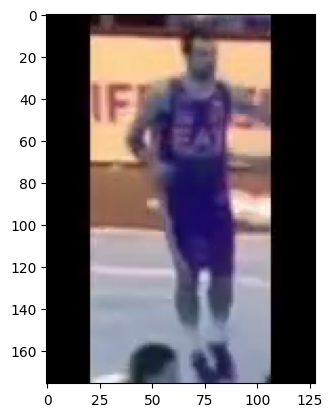

In [20]:
plt.imshow(example_frame);

A imagem aqui foi convertida com a função cvtColor para que seja mostrada da forma usual em RGB 

NÃO existe certo ou errado na hora de usar as imagens em BGR ou em RGB nos modelos posteriormente. Em termos de visualização principalmente, é bem melhor usar RGB então é isso que vou fazer aqui. Precisar converter as imagens em RGB tanto no treinamento como na inferência adiciona um overhead de processamento inegável, porém ínfimo para os sistemas de hoje em dia, então nada que seja de fato importante

O que de fato é importante é ser consistente: Treinou em RGB? Inferência em RGB. Treinou em BGR? Inferência em BGR

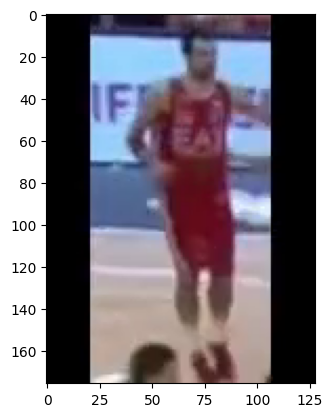

In [56]:
example_frame_rgb = cv2.cvtColor(example_frame, cv2.COLOR_BGR2RGB)
example_frame_2_rgb = cv2.cvtColor(example_frame_2, cv2.COLOR_BGR2RGB)
plt.imshow(example_frame_rgb);

Todos os frames de todos os vídeos possuem tamanho 176x128. Note que o frame mostrado possui algumas barras pretas ao lado. O modelo vai receber muitos frames pretos, e pode ser interessante pensar em estratégias de fazer com que o modelo foque em partes mais específicas da imagem na hora de tomar uma decisão. Abordarei isso mais depois

In [24]:
example_frame_rgb.shape

(176, 128, 3)

## Operações com Imagens

Especificamente, vou focar aqui nas operações geralmente utilizadas para os modelos durante o Data Augmentation (Aumento de Dados)

### Flip

flipCode = 1 - Flip Horizontal <br>
flipCode = 0 - Flip Vertical <br>
flipCode = -1 - Flip nos 2 sentidos

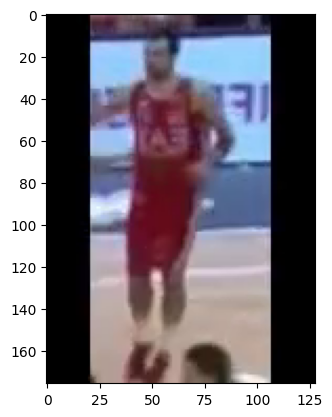

In [31]:
plt.imshow(cv2.flip(example_frame_rgb, flipCode=1));

### Crop

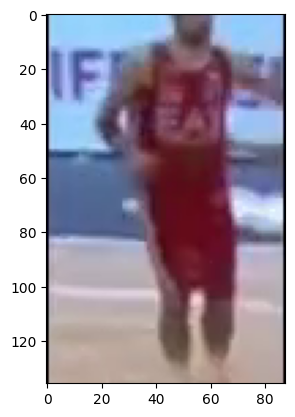

In [35]:
h, w, c = example_frame_rgb.shape

# cortando 20 pixels de cada borda)
y_start, y_end = 20, h - 20
x_start, x_end = 20, w - 20

cropped_frame = example_frame_rgb[y_start:y_end, x_start:x_end]
plt.imshow(cropped_frame);

### Rotação

Um ângulo positivo significa rotação no sentido-horário. Negativo, no sentido anti-horário

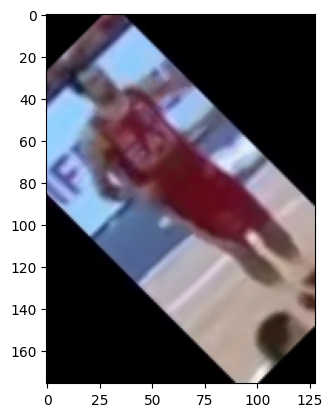

In [37]:
h, w, c = example_frame_rgb.shape
center = (w // 2, h // 2)

# Criando a matriz de rotação
rotation_matrix = cv2.getRotationMatrix2D(center, angle=45, scale=1.0)

# Aplicando a transformação na imagem
rotated_frame = cv2.warpAffine(example_frame_rgb, rotation_matrix, (w, h))

plt.imshow(rotated_frame);

### Translação

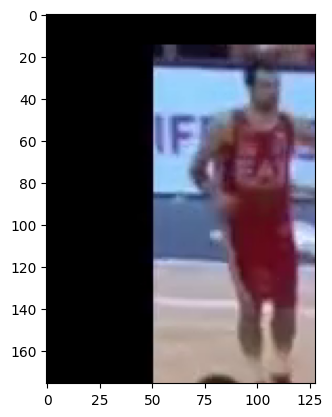

In [39]:
tx, ty = 30, 15

# Matriz de translação
# [1, 0, tx]
# [0, 1, ty]
translation_matrix = np.float32([[1, 0, tx], [0, 1, ty]])

translated_frame = cv2.warpAffine(example_frame_rgb, translation_matrix, (w, h))

plt.imshow(translated_frame);

### Cutout

A ideia dessa técnica é literalmente cortar uma parte da imagem e forçar o modelo a não focar em características específicas das imagens, e sim aprender de forma mais geral o porquê da imagem ser daquela classe

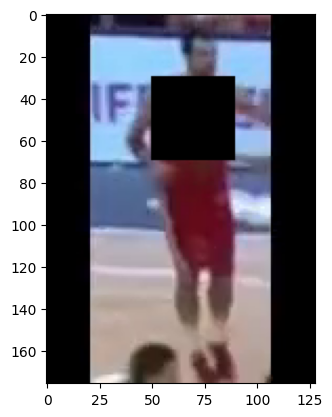

In [41]:
cutout_frame = example_frame_rgb.copy()

# Tamanho do quadrado a ser cortado
box_size = 40

# Posição aleatória
x_cut = 50
y_cut = 30

cutout_frame[y_cut:y_cut+box_size, x_cut:x_cut+box_size] = 0

plt.imshow(cutout_frame);

### Contrast

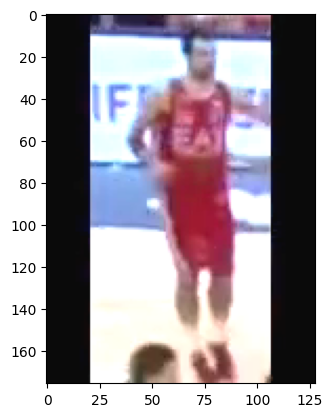

In [43]:
alpha = 1.5 
beta = 10

contrast_frame = cv2.convertScaleAbs(example_frame_rgb, alpha=alpha, beta=beta)

plt.imshow(contrast_frame);

### MixUp

Aqui, há uma tentativa de misturar 2 imagens para criar uma nova imagem bem diferente que o modelo ainda sim tem que tentar acertar. A nova imagem terá o label da imagem que possui mais predominância no final

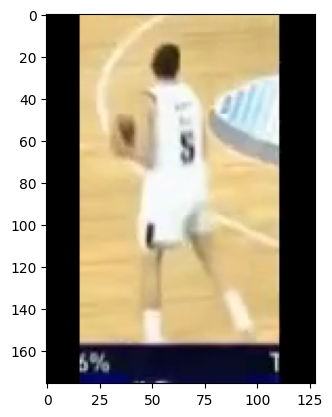

In [57]:
plt.imshow(example_frame_2_rgb);

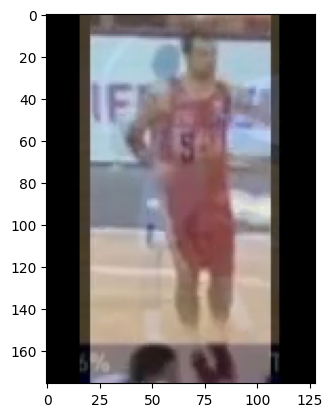

In [59]:
lambda_val = 0.7 # Qual imagem será predominante no final
mixup_frame = cv2.addWeighted(example_frame_rgb, lambda_val, example_frame_2_rgb, 1 - lambda_val, gamma=0.0)

plt.imshow(mixup_frame);

### CutMix

Uma mistura de MixUp e CutOut, em que pegamos partes de uma imagem A, cortamos essa partes e colocamos diretamente na imagem B

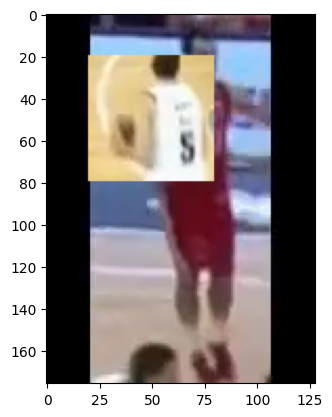

In [61]:
cutmix_frame = example_frame_rgb.copy()

box_w, box_h = 60, 60
start_x, start_y = 20, 20

cutmix_frame[start_y:start_y+box_h, start_x:start_x+box_w] = example_frame_2_rgb[start_y:start_y+box_h, start_x:start_x+box_w]

plt.imshow(cutmix_frame);